This notebook is for seeing the data collected for imitation learning.

In [14]:
import numpy as np

data = np.load(r"C:\Users\Furkan\Desktop\Kod\Metadrive Autonomous\data\raw\episode_0.npz")

Dosya içeriği (5 bileşen): ['action', 'cam_0', 'cam_180', 'depth_0', 'depth_180']


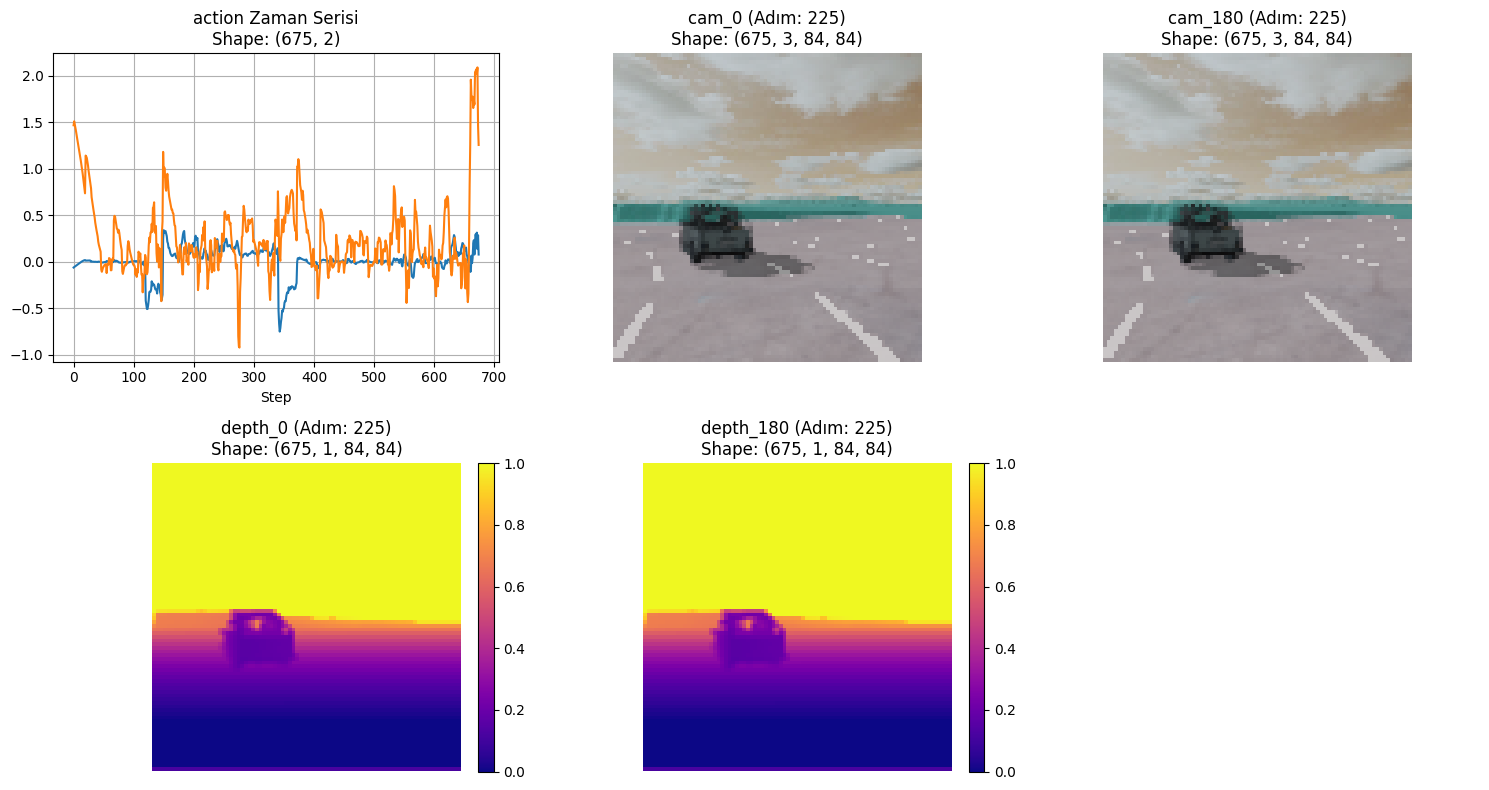

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math

def visualize_npz(file_path):
    if not os.path.exists(file_path):
        print(f"Hata: {file_path} bulunamadı.")
        return

    data = np.load(file_path)
    keys = list(data.keys())
    print(f"Dosya içeriği ({len(keys)} bileşen): {keys}")

    n_keys = len(keys)
    
    # --- DİNAMİK IZGARA (GRID) DÜZENİ ---
    # Görüntüleri alt alta dizmek yerine 3 sütunlu bir tablo (grid) oluşturuyoruz
    cols = 3
    rows = math.ceil(n_keys / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    
    # Eksenleri (axes) tek boyutlu bir listeye çeviriyoruz ki döngüde dönmek kolay olsun
    if n_keys == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, key in enumerate(keys):
        arr = data[key]
        ax = axes[i]
        
        # ==========================================
        # 1. GÖRÜNTÜ VERİSİ KONTROLÜ (Kamera/Derinlik)
        # ==========================================
        # Eğer dizi 4 boyutluysa (Step, C, H, W) veya (Step, H, W, C) bunu görüntü kabul et
        if arr.ndim == 4:
            # GÜVENLİK ÖNLEMİ: Bölüm kısa sürdüyse Index hatası almamak için
            # Bölümün tam ortasındaki anı seçiyoruz. İstersen -1 yazarak en son anı da alabilirsin.
            target_step = arr.shape[0] // 3 
            img = arr[target_step]
            
            # Gereksiz 1'lik boyutları at (Örn: 1, 84, 84 -> 84, 84)
            img = np.squeeze(img)
            
            # (C, H, W) -> (H, W, C) dönüşümü (PyTorch formatından Matplotlib formatına)
            if img.ndim == 3 and img.shape[0] in [1, 3, 4]:
                img = img.transpose(1, 2, 0)
                if img.shape[-1] == 1: # Tek kanallı ise tekrar squeeze
                    img = img.squeeze(-1)

            # --- DERİNLİK (DEPTH) İÇİN ÖZEL ---
            if 'depth' in key.lower():
                img_min, img_max = np.min(img), np.max(img)
                if img_max > img_min: 
                    img_normalized = (img - img_min) / (img_max - img_min)
                else:
                    img_normalized = img
                
                im = ax.imshow(img_normalized, cmap='plasma')
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04) 
            
            # --- RGB KAMERALAR İÇİN ---
            # 'rgb' adında olmasına gerek yok, 4 boyutluysa ve 'depth' değilse standart resimdir
            else:
                if img.max() > 1.0:
                    img = img.astype(np.uint8)
                ax.imshow(img)
                
            ax.set_title(f"{key} (Adım: {target_step})\nShape: {arr.shape}")
            ax.axis('off')
            
        # ==========================================
        # 2. ZAMAN SERİSİ VERİSİ (Aksiyon, Ödül vb.)
        # ==========================================
        elif arr.ndim <= 2:
            ax.plot(arr)
            ax.set_title(f"{key} Zaman Serisi\nShape: {arr.shape}")
            ax.set_xlabel("Step")
            ax.grid(True)
            
        # Diğer formatlar için hata mesajı
        else:
            ax.text(0.5, 0.5, f"{key}:\nDesteklenmeyen boyut\n{arr.shape}", 
                    ha='center', va='center')
            ax.set_title(key)

    # --- BOŞ KALAN GRAFİK KUTULARINI GİZLEME ---
    # Eğer 13 grafik varsa, 3 sütunlu yapıda 15 kutu oluşur. Son 2 boş kutuyu gizliyoruz.
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Kullanım:
visualize_npz(r"C:\Users\Furkan\Desktop\Kod\Metadrive Autonomous\data\raw\episode_0.npz")

In [3]:
keys = list(data.keys())
print(f"Dosya içeriği: {keys}")

Dosya içeriği: ['rgb', 'depth', 'action']


In [21]:
data.get("action")[0]

array([-0.12874566,  1.3514872 ], dtype=float32)